# 穷举的困境：无限膨胀的类别

## 介绍

## 知识点


## 环境版本

In [22]:
from util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 观察数据

In [23]:
# 打开文件并读取前5行
from util import show_first_n_lines

show_first_n_lines('../dataset/addition.txt', 5)

,行数,内容
0,1,16+75 =91
1,2,52+607 =659
2,3,75+22 =97
3,4,63+22 =85
4,5,795+3 =798


## 自定义分词器

In [24]:
from util import print_table
import torch

class SimpleTokenizer:
    def __init__(self, vocab, pad_token, unk_token):
        """
        初始化简单分词器
        """

        self.vocab = vocab

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}


        # 特殊token
        self.pad_token = pad_token
        self.pad_token_id = self.vocab[pad_token]
        
        self.unk_token = unk_token
        self.unk_token_id = self.vocab[unk_token]
        
        self.special_tokens = [self.pad_token, self.unk_token]
        
        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def encode(self, text):
        # 将文本拆分为单个字符和特殊标记
        tokens = self._tokenize_special_tokens(text)

        # 将每个token转换为对应的token ID
        input_ids = [self.vocab[token] for token in tokens if token in self.vocab]

        return input_ids

    def _tokenize_special_tokens(self, text):
        # 识别并处理特殊标记
        tokens = []
        i = 0
        while i < len(text):
            # 检查是否匹配特殊标记
            for token in self.special_tokens:
                if text[i:i + len(token)] == token:
                    tokens.append(token)
                    i += len(token)
                    break
            else:
                # 如果不是特殊标记，则逐个字符处理
                tokens.append(text[i])
                i += 1
        return tokens


    def decode(self, input_ids, skip_special_tokens=True):
        # 如果 input_ids 是 torch.Tensor，则转换为列表
        if isinstance(input_ids, torch.Tensor):
            input_ids = input_ids.squeeze().tolist()

        # 将token ID序列转换为对应的字符
        tokens = [self.ids_to_tokens.get(id) for id in input_ids]

        # 去除开始符和结束符
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in self.special_tokens]
        return ''.join(tokens)

    def __call__(self, texts):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        if is_single_text:
            all_token_ids = all_token_ids[0]

        return all_token_ids

    def info(self):
        """
        打印分词器的详细信息
        """

        # 通用信息表
        print_table("General Information", field_names=["Information", "Value"], data=[
            ["Vocabulary Size", self.vocab_size],
            ["Padding Token", f"{self.pad_token} (ID: {self.pad_token_id})"]
        ])

        # 字符到ID的映射表
        print_table("Token Mapping", field_names=["Token", "ID"], data=[
            [char, char_id] for char, char_id in self.vocab.items()
        ])

        # 编码解码示例表
        example = "52+607 "  # 示例输入
        print_table("Encoding and Decoding Example", field_names=["Input", "Encode", "Decode"], data=[
            [example, self.encode(example), self.decode(self.encode(example))],
        ])

In [25]:
vocab = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "+": 10,
    "=": 11,
    " ": 12,
    "<|unk|>": 13,
}

tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")  # 初始化分词器
tokenizer.info()  # 打印分词器信息


General Information：
+-----------------+------------+
|   Information   |   Value    |
+-----------------+------------+
| Vocabulary Size |     14     |
|  Padding Token  |   (ID: 12) |
+-----------------+------------+

Token Mapping：
+---------+----+
|  Token  | ID |
+---------+----+
|    0    | 0  |
|    1    | 1  |
|    2    | 2  |
|    3    | 3  |
|    4    | 4  |
|    5    | 5  |
|    6    | 6  |
|    7    | 7  |
|    8    | 8  |
|    9    | 9  |
|    +    | 10 |
|    =    | 11 |
|         | 12 |
| <|unk|> | 13 |
+---------+----+

Encoding and Decoding Example：
+---------+-------------------------+--------+
|  Input  |          Encode         | Decode |
+---------+-------------------------+--------+
| 52+607  | [5, 2, 10, 6, 0, 7, 12] | 52+607 |
+---------+-------------------------+--------+


## 数据转换

In [26]:
class TextTransform:
    def __init__(self, tokenizer: SimpleTokenizer, max_length=20):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, text):
        input_ids = self.tokenizer(text)
        return torch.tensor(input_ids, dtype=torch.long)

## 构造数据集

In [27]:
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform: TextTransform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)
        
        # 假设此处是原始代码位置
        if isinstance(label, list):
            # 如果 label 是列表，可以选择全部或部分元素
            answer = [str(l) for l in label]  # 支持切片操作，例如 [:2] 或 [1:3]
        else:
            answer = str(label)

        return {
            "question": text,  # 原始问题文本
            "answer": answer,  # 原始答案文本
            'input_ids': input_ids,
            'labels': label
        }

    @classmethod
    def from_file(cls, file_path, transform: TextTransform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip() == '':  # 跳过空行
                    continue
                try:
                    # 查找等号的位置，将行分割为问题和答案
                    idx = line.find('=')
                    # 将样本添加到列表中: (question, answer)，answer中去掉"="以及最后的"\n"
                    question = line[:idx]
                    answer = line[idx + 1:].strip()
                    texts.append(question)
                    labels.append(int(answer))
                except Exception as e:
                    # 如果处理某行时出错，打印错误信息并跳过
                    print(f"Error processing line: {line}")
                    print(f"Error message: {e}")
                    continue

        # 创建数据集实例
        return cls(texts, labels, transform)

In [28]:
from pprint import pprint

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=7)


# 3️⃣ 加载数据集
file_path = "../dataset/addition.txt"
dataset = TextClassificationDataset.from_file(file_path, transform=transform)

pprint(dataset[:2], sort_dicts=False)

{'question': ['16+75  ', '52+607 '],
 'answer': ['91', '659'],
 'input_ids': tensor([[ 1,  6, 10,  7,  5, 12, 12],
        [ 5,  2, 10,  6,  0,  7, 12]]),
 'labels': [91, 659]}


## 初始化数据模组

In [29]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform: TextTransform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        self.train_data_file = train_data_file
        self.val_data_file = val_data_file
        self.test_data_file = test_data_file

        self.test_dataset = None
        self.val_dataset = None
        self.train_dataset = None

        self.batch_size = batch_size
        self.transform = transform

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        pass

    def setup(self, stage=None):
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file, transform=self.transform)
        
        # 加载验证数据集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            self.val_dataset = TextClassificationDataset.from_file(self.val_data_file, transform=self.transform)
        
        # 加载测试数据集
        if self.test_data_file == "":
            self.test_dataset = self.train_dataset
        else:
            self.test_dataset = TextClassificationDataset.from_file(self.test_data_file, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [30]:
from pprint import pprint

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=7)

# 3️⃣ 加载数据模组
file_path = "../dataset/addition.txt"
text_datamodule = TextDataModule(batch_size=2, transform=transform, train_data_file=file_path)

# 调用 setup 方法初始化数据集
text_datamodule.setup()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in text_datamodule.train_dataloader():
    pprint(batch, sort_dicts=False)
    break

打印一个批次的数据：
{'question': ['216+421', '556+61 '],
 'answer': ['637', '617'],
 'input_ids': tensor([[ 2,  1,  6, 10,  4,  2,  1],
        [ 5,  5,  6, 10,  6,  1, 12]]),
 'labels': tensor([637, 617])}


## 构建模型

In [31]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, vocab_size, hidden_size, num_classes, learning_rate=0.01, dropout_p=0.1):
        super(TextClassifier, self).__init__()

        # 学习率, 用于设置优化器
        self.learning_rate = learning_rate
        # 标签id到标签的映射，用于预测解码
        self.ids_to_labels = None

        # 定义网络层
        # 嵌入层：将词索引映射到高维向量
        self.token_emb = nn.Embedding(vocab_size, hidden_size)
        # GRU层：用于处理序列数据
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        # Dropout层：防止过拟合
        self.dropout = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.randint(0, vocab_size, (32, 10), dtype=torch.long)

    def forward(self, input_ids):
        """前向传播"""
        token_embeds = self.dropout(self.token_emb(input_ids))  # 嵌入并应用dropout
        gru_output, gru_hidden = self.gru(token_embeds)  # 通过GRU处理, 得到输出和隐藏状态

        # 取出最后一层的隐藏状态（对于单层GRU，索引为-1或0都可以）
        last_hidden = gru_hidden[-1]  # 形状: (batch_size, hidden_size)

        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_hidden)  # 形状: (batch_size, num_classes)

        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': labels})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, ids_to_labels=None):
        """根据数据集设置标签映射"""
        self.ids_to_labels = ids_to_labels

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.ids_to_labels[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.ids_to_labels[label_id] for label_id in label_ids]

In [32]:
# 创建从0到1998的ids_to_labels映射（用于三位数以内的加法）
ids_to_labels = {i: str(i) for i in range(1999)}

from lightning.pytorch.utilities.model_summary import ModelSummary

model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=len(ids_to_labels),
                       learning_rate=0.001)

summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name         | Type      | Params | Mode  | FLOPs  | In sizes      | Out sizes                    
------------------------------------------------------------------------------------------------------------
0 | token_emb    | Embedding | 1.8 K  | train | 0      | [32, 10]      | [32, 10, 128]                
1 | gru          | GRU       | 99.1 K | train | 62.9 M | [32, 10, 128] | [[32, 10, 128], [1, 32, 128]]
2 | dropout      | Dropout   | 0      | train | 0      | [32, 10, 128] | [32, 10, 128]                
3 | output_layer | Linear    | 257 K  | train | 16.4 M | [32, 128]     | [32, 1999]                   
------------------------------------------------------------------------------------------------------------
358 K     Trainable params
0         Non-trainable params
358 K     Total params
1.435     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
79.3 M    Total Flops


## 初始化模型

In [33]:
max_length = 7
batch_size = 32

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab, pad_token=" ", unk_token="<|unk|>")

# 2️⃣ 初始化数据转换
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 加载数据模组
file_path = "../dataset/addition.txt"
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file=file_path)

# 4️⃣ 初始化模型
model = TextClassifier(vocab_size=tokenizer.vocab_size, hidden_size=128, num_classes=len(ids_to_labels),
                       learning_rate=0.001)

# 5️⃣ 初始化训练器
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0, enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


## 训练前评估

In [34]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │           38.0            │
│       total_samples       │          50000.0          │
│      val_overall_acc      │   0.0007600000244565308   │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 50000.0,
  'total_correct': 38.0,
  'val_overall_acc': 0.0007600000244565308}]

## 训练模型

In [35]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type      ┃ Params ┃ Mode  ┃  FLOPs ┃      In sizes ┃                     Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ token_emb    │ Embedding │  1.8 K │ train │      0 │      [32, 10] │                 [32, 10, 128] │
│ 1 │ gru          │ GRU       │ 99.1 K │ train │ 62.9 M │ [32, 10, 128] │ [[32, 10, 128], [1, 32, 128]] │
│ 2 │ dropout      │ Dropout   │      0 │ train │      0 │ [32, 10, 128] │                 [32, 10, 128] │
│ 3 │ output_layer │ Linear    │  257 K │ train │ 16.4 M │     [32, 128] │                    [32, 1999] │
└───┴──────────────┴───────────┴────────┴───────┴────────┴───────────────┴───────────────────────────────┘

Trainable params: 358 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 358 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 79.3 M

`Trainer.fit` stopped: `max_epochs=12` reached.


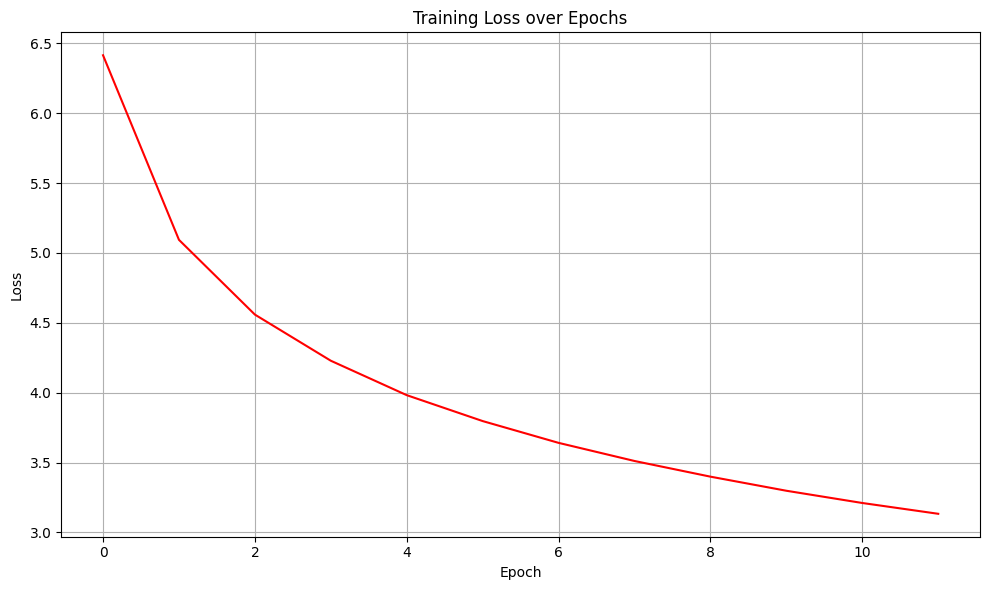

In [36]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

In [37]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,50000,879,0.0176
1,1,50000,1871,0.0374
2,2,50000,2851,0.0570
3,3,50000,3980,0.0796
4,4,50000,4673,0.0935
5,5,50000,5700,0.1140
6,6,50000,6437,0.1287
7,7,50000,7108,0.1422
8,8,50000,7695,0.1539
9,9,50000,8500,0.1700


## 训练后评估

In [38]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          9568.0           │
│       total_samples       │          50000.0          │
│      val_overall_acc      │    0.1913599967956543     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 50000.0,
  'total_correct': 9568.0,
  'val_overall_acc': 0.1913599967956543}]

## 使用模型进行预测

In [40]:
model.setup_label_map(ids_to_labels=ids_to_labels)

from util import print_classification_results


questions = ["829+33 ", "58+136 ", "22+593 ", "243+269", "1+1    "]
answers = [862, 194, 615, 512, 2]


# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in questions:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)


# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

print(predictions, decoded_predictions)

# 4. 输出预测结果
print_classification_results(questions, answers, predictions, probabilities, model.ids_to_labels)

[864, 191, 611, 513, 10] ['864', '191', '611', '513', '10']

🎯 分类预测结果 (准确率: 0/5 = 0.00%)：
+---------+----------+----------+----------+------+
|   输入  | 真实标签 | 预测标签 | 最高概率 | 标记 |
+---------+----------+----------+----------+------+
| 829+33  |   862    |   864    |  0.1723  |  ☒   |
| 58+136  |   194    |   191    |  0.1451  |  ☒   |
| 22+593  |   615    |   611    |  0.1494  |  ☒   |
| 243+269 |   512    |   513    |  0.0899  |  ☒   |
| 1+1     |    2     |    10    |  0.3906  |  ☒   |
+---------+----------+----------+----------+------+


## 模型测试

In [41]:
from util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="../dataset/addition.txt",
                             val_data_file="../dataset/addition.txt",
                             test_data_file="../dataset/addition.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          9568.0           │
│       total_samples       │          50000.0          │
│      val_overall_acc      │    0.1913599967956543     │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          9568.0           │
│       total_samples       │          50000.0          │
│      val_overall_acc      │    0.1913599967956543     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 50000.0,
  'total_correct': 9568.0,
  'val_overall_acc': 0.1913599967956543}]

## 拓展阅读

## 存在的问题

思考一下，引出下一章